Alunos:
Allan Samuel - 24101279
Guilherme Portas - 24101108
Thiago Dellano - 

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import floor, ceil

df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [38]:
colunasSensiveis = ["age", "fnlwgt", "capital.gain", "capital.loss"]

In [39]:
def anonimizacao(valor, variacaoMax = 0.2, variacaoMin = 0.1):
    if(pd.isnull(valor) or valor == 0): return np.nan
    randomMenor = np.random.uniform(variacaoMin, variacaoMax) # Perturbacao
    randomMaior = np.random.uniform(variacaoMin, variacaoMax)
    valorMenor = int(floor(valor * (1 - randomMenor) / 10) * 10)
    valorMaior = int(ceil(valor * (1 + randomMaior) / 10) * 10)
    return f"{valorMenor} - {valorMaior}"

In [40]:
for col in colunasSensiveis:
    df[col] = df[col].apply(anonimizacao)

print(df)

            age workclass           fnlwgt     education  education.num  \
0      70 - 110         ?    69150 - 85250       HS-grad              9   
1      60 - 100   Private  111650 - 146180       HS-grad              9   
2       50 - 80         ?  162750 - 205410  Some-college             10   
3       40 - 70   Private  114010 - 166880       7th-8th              4   
4       30 - 50   Private  236210 - 291140  Some-college             10   
...         ...       ...              ...           ...            ...   
32556   10 - 30   Private  250450 - 343090  Some-college             10   
32557   20 - 40   Private  223630 - 306940    Assoc-acdm             12   
32558   30 - 50   Private  124230 - 169950       HS-grad              9   
32559   50 - 70   Private  136020 - 175190       HS-grad              9   
32560   10 - 30   Private  175050 - 224050       HS-grad              9   

           marital.status         occupation   relationship   race     sex  \
0                 Wid

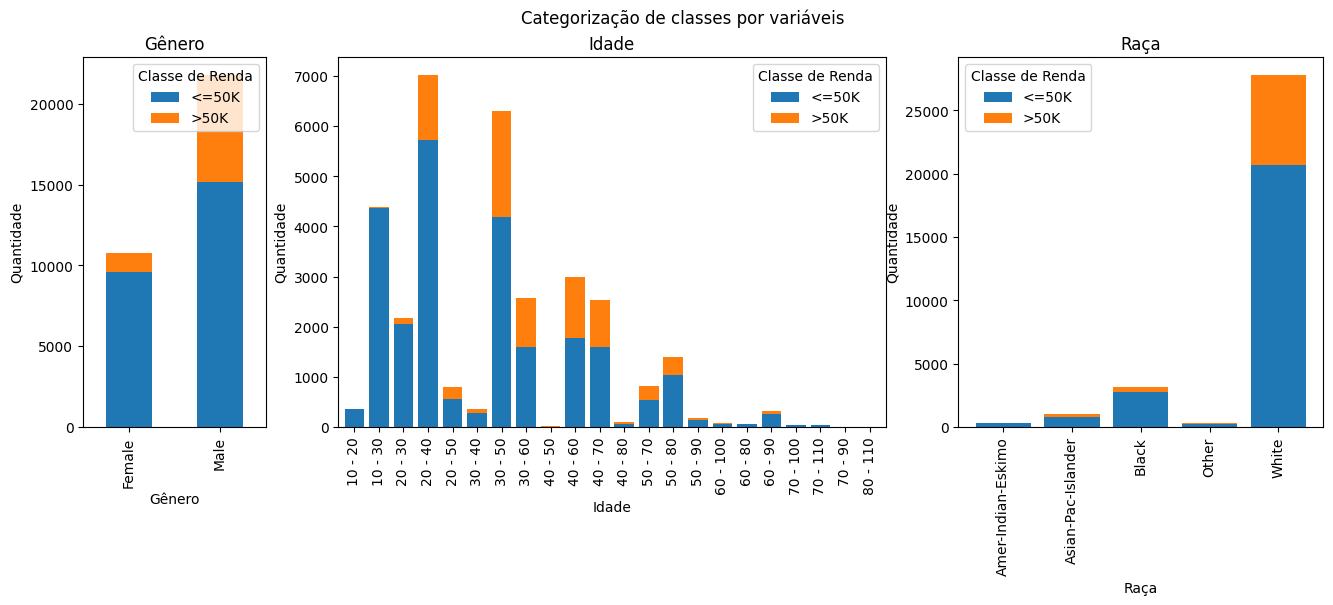

In [41]:
fig, ax = plt.subplots(1, 3, width_ratios=[1, 3, 2])
fig.set_figwidth(16)
fig.suptitle("Categorização de classes por variáveis")

sex_income = df.groupby(['sex', 'income']).size().unstack()
sex_income.plot(kind='bar', stacked=True, ax=ax[0])
ax[0].set_title('Gênero')
ax[0].set_xlabel('Gênero')
ax[0].set_ylabel('Quantidade')
ax[0].legend(title='Classe de Renda')

age_income = df.groupby(['age','income']).size().unstack()
age_income.plot(kind='bar', stacked=True, width=0.8, ax=ax[1])
ax[1].set_title('Idade')
ax[1].set_xlabel('Idade')
ax[1].set_ylabel('Quantidade')
ax[1].legend(title='Classe de Renda')

race_income = df.groupby(['race', 'income']).size().unstack()
race_income.plot(kind='bar', stacked=True, width=0.8, ax=ax[2])
ax[2].set_title('Raça')
ax[2].set_xlabel('Raça')
ax[2].set_ylabel('Quantidade')
ax[2].legend(title='Classe de Renda')

plt.show()